# Обучение моделей

In [45]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 4)

In [46]:
from pathlib import Path

path_p1_p2 = Path("..", "data", "processed", "p1_p2_data.csv")
df_p1_p2 = pd.read_csv(path_p1_p2, sep=";")

path_p3 = Path("..", "data", "processed", "p3_data.csv")
df_p3 = pd.read_csv(path_p3, sep=";")

path_altpay5 = Path("..", "data", "processed", "altpay5_data.csv")
df_altpay5 = pd.read_csv(path_altpay5, sep=";")

dfs = [df_p1_p2, df_p3, df_altpay5]

COMMON_DTTM_COLS = [
    'month',
    'first_trx_month_inn',
    'last_active_month_inn',
]

CAT_COLS = [
    'inn_status',
    'top_mcc_group_inn',
    'who_is_this_first_inn',
]

for df in dfs:
    for col in COMMON_DTTM_COLS:
        df[col] = pd.to_datetime(df[col])

    # В каждом df разный набор колонок с датами подключения других продуктов
    first_month_cols = [col for col in df.columns if col.startswith("first_month")]
    for col in first_month_cols:
        df[col] = pd.to_datetime(df[col])

    for col in CAT_COLS:
        df[col] = df[col].astype('category')

## Метрики качества
Основной метрикой качества моделей является Precision@K, поскольку бизнес-задача заключается в эффективном распределении ограниченного ресурса отдела продаж. В рамках задачи capacity отдела составляет 2000 клиентов в месяц, что определяет основное значение K. Дополнительно рассматриваются значения K=500, K=1000 и K=1500 для анализа устойчивости качества ранжирования.

Для оценки относительного качества моделей используется метрика Uplift — отношение Precision@K рассматриваемой модели к Precision@K базовых подходов. В качестве базовых подходов используются:

1. Случайный отбор клиентов
2. Отбор на основе текущих бизнес-правил

Дополнительно для оценки качества ранжирования анализируется зависимость Precision@K от K, что позволяет оценить способность модели выделять наиболее релевантных клиентов в верхней части ранжированного списка.

Также используется метрика Recall@K, отражающая долю всех целевых событий (подключений продукта), попадающих в top-K клиентов, что позволяет оценить полноту охвата моделью потенциально релевантных клиентов.

Для интерпретации результатов в бизнес-терминах рассчитывается ожидаемое количество подключений (Expected Conversions), определяемое как произведение Precision@K на K.

## Случайный отбор


### P1P2

Для случайной модели ранжирования ожидаемое значение Precision@K совпадает с долей положительных объектов в выборке. В связи с этим в качестве baseline используется доля положительного класса, рассчитанная по каждому месяцу.

Random Baseline
Precision@K=0.23% (std=0.05% min=0.16%, max=0.37%)


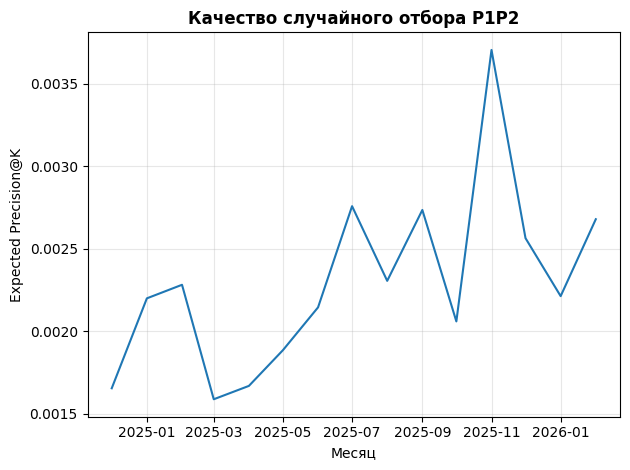

In [47]:
random_baseline_p1_p2 = (
    df_p1_p2.groupby('month')['target'].sum()
    / df_p1_p2.groupby('month').size()
)

random_baseline_p1_p2_stats = {
    'mean': np.nanmean(random_baseline_p1_p2),
    'std': np.nanstd(random_baseline_p1_p2),
    'min': np.nanmin(random_baseline_p1_p2),
    'max': np.nanmax(random_baseline_p1_p2),
    'per_month': random_baseline_p1_p2,
}

print(
    "Random Baseline\n"
    f"Precision@K={random_baseline_p1_p2_stats['mean']:.2%} (std={random_baseline_p1_p2_stats['std']:.2%} "
    f"min={random_baseline_p1_p2_stats['min']:.2%}, max={random_baseline_p1_p2_stats['max']:.2%})"
)

sns.lineplot(data=random_baseline_p1_p2.reset_index(), x=random_baseline_p1_p2.index, y=0)

plt.title("Качество случайного отбора P1P2", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Expected Precision@K")

plt.tight_layout()
plt.grid(alpha=0.3)

plt.show()

Качество случайного отбора ожидаемо неустойчиво по месяцам. Возможно, подключения имеют выраженную сезонность, из-за чего во втором полугодии наблюдается более высокая доля подключений среди всех наблюдений в сравнении с первым полугодием.

### P3

Random Baseline
Precision@K=0.01% (std=0.01% min=0.00%, max=0.03%)


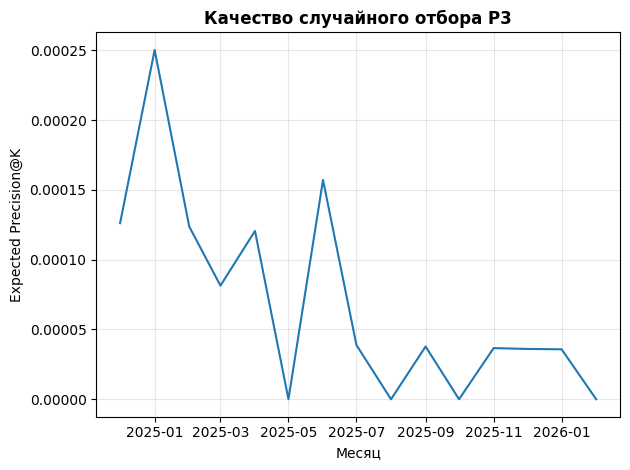

In [48]:
random_baseline_p3 = (
    df_p3.groupby('month')['target'].sum()
    / df_p3.groupby('month').size()
)

random_baseline_p3_stats = {
    'mean': np.nanmean(random_baseline_p3),
    'std': np.nanstd(random_baseline_p3),
    'min': np.nanmin(random_baseline_p3),
    'max': np.nanmax(random_baseline_p3),
    'per_month': random_baseline_p3,
}

print(
    "Random Baseline\n"
    f"Precision@K={random_baseline_p3_stats['mean']:.2%} (std={random_baseline_p3_stats['std']:.2%} "
    f"min={random_baseline_p3_stats['min']:.2%}, max={random_baseline_p3_stats['max']:.2%})"
)

sns.lineplot(data=random_baseline_p3.reset_index(), x=random_baseline_p3.index, y=0)

plt.title("Качество случайного отбора P3", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Expected Precision@K")

plt.tight_layout()
plt.grid(alpha=0.3)

plt.show()

### Altpay5

Random Baseline
Precision@K=0.14% (std=0.06% min=0.00%, max=0.26%)


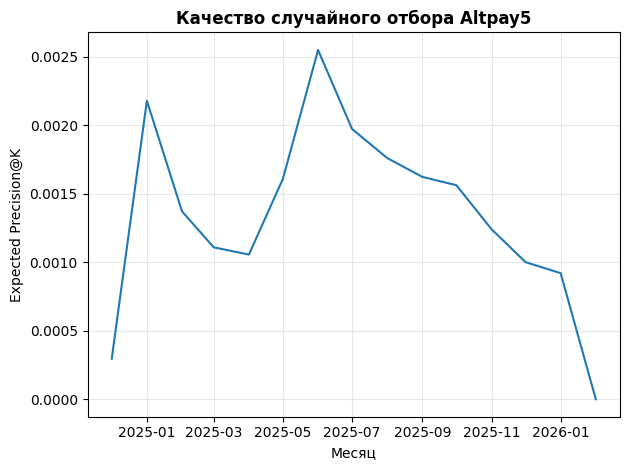

In [49]:
random_baseline_altpay5 = (
    df_altpay5.groupby('month')['target'].sum()
    / df_altpay5.groupby('month').size()
)

random_baseline_altpay5_stats = {
    'mean': np.nanmean(random_baseline_altpay5),
    'std': np.nanstd(random_baseline_altpay5),
    'min': np.nanmin(random_baseline_altpay5),
    'max': np.nanmax(random_baseline_altpay5),
    'per_month': random_baseline_altpay5,
}

print(
    "Random Baseline\n"
    f"Precision@K={random_baseline_altpay5_stats['mean']:.2%} (std={random_baseline_altpay5_stats['std']:.2%} "
    f"min={random_baseline_altpay5_stats['min']:.2%}, max={random_baseline_altpay5_stats['max']:.2%})"
)

sns.lineplot(data=random_baseline_altpay5.reset_index(), x=random_baseline_altpay5.index, y=0)

plt.title("Качество случайного отбора Altpay5", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Expected Precision@K")

plt.tight_layout()
plt.grid(alpha=0.3)

plt.show()

## Rule-Based модели
Существуют правила, по которым бизнес на текущий момент определяет релевантность продуктов `P1P2, P3 и Altpay5`. Построим модели, основываясь на них.

### P1P2
Критерии релевантности:
- Отсутствие подключённых продуктов `P1`, `P2`
- Статус `'Active'`, `'Reborn'`
- Группа MCC `!= 'Charity'`

Результат ранжируется по убыванию `turnover`

In [50]:
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional
from sklearn.base import BaseEstimator, ClassifierMixin


@dataclass
class P1P2RuleConfig:
    active_statuses: List[str] = field(default_factory=lambda: ["Active", "Reborn"])
    banned_mcc_groups: List[str] = field(default_factory=lambda: ["Charity"])


class P1P2BusinessRuleModel(BaseEstimator, ClassifierMixin):
    """
    Rule-based модель релевантности P1P2.
    """

    required_columns = ["inn_status", "top_mcc_group_inn"]

    def __init__(self, config: Optional[P1P2RuleConfig] = None):
        self.config = config if config is not None else P1P2RuleConfig()
        self.is_fitted_ = False

    def _validate_input(self, X: pd.DataFrame):
        missing = [c for c in self.required_columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

    def _check_fitted(self):
        if not self.is_fitted_:
            raise RuntimeError("Model is not fitted. Call fit() first.")

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None):
        self._validate_input(X)
        self.is_fitted_ = True
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        self._check_fitted()
        self._validate_input(X)

        pred = (
            X["inn_status"].isin(self.config.active_statuses)
            & ~X["top_mcc_group_inn"].isin(self.config.banned_mcc_groups)
        ).astype("int8")

        return pred.to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Метод необходим для совместимости с sklearn. Возможные вероятности для Rule-based моделей: 0, 1."""
        pred = self.predict(X)
        proba_1 = pred.astype(float)
        proba_0 = 1.0 - proba_1
        return np.column_stack([proba_0, proba_1])

    def explain_rules(self) -> Dict[str, Any]:
        return {
            "active_statuses": self.config.active_statuses,
            "banned_mcc_groups": self.config.banned_mcc_groups,
            "logic": "prediction=1 if status in active_statuses and top_mcc_group_inn not in banned_mcc_groups"
        }


X = df_p1_p2.copy()
y = df_p1_p2["target"].astype("int8")

rule_model_p1_p2 = P1P2BusinessRuleModel()
rule_model_p1_p2.fit(X, y)

df_pred_p1_p2 = X.copy()
df_pred_p1_p2["y"] = y.values
df_pred_p1_p2["y_pred"] = rule_model_p1_p2.predict(X)

Замерим качество построенной модели по Precision@K и визуализируем результат по месяцам в сравнении с random_baseline.

Rule-Based Model P1P2 Validation
Precision@500  = 0.56% (std=0.37%, min=0.00%, max=1.40%)
Precision@1000 = 0.53% (std=0.16%, min=0.20%, max=0.80%)
Precision@1500 = 0.51% (std=0.14%, min=0.27%, max=0.80%)
Precision@2000 = 0.47% (std=0.13%, min=0.25%, max=0.75%)


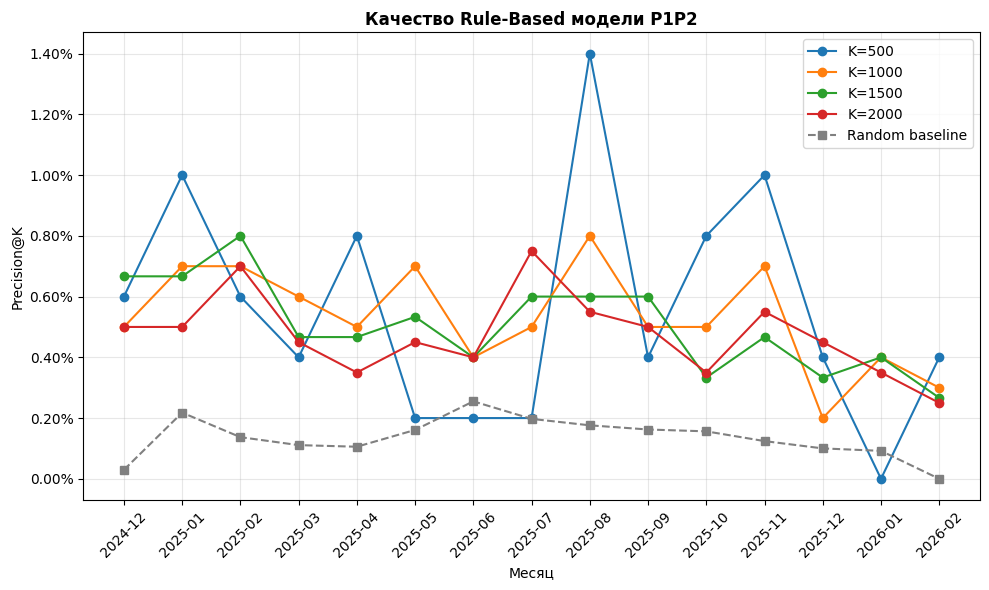

In [51]:
def precision_at_k_by_month(
    data: pd.DataFrame,
    k: int,
    y_true: str = "y",
    score_col: str = "turnover",
    month_col: str = "month",
):
    """
    Считает Precision@K по месяцам и агрегирует.
    Возвращает:
    - mean 
    - std
    - min
    - max
    - per_month dict
    """
    precisions = []
    month_labels = []

    for month, g in data.groupby(month_col):
        g = g.sort_values(score_col, ascending=False)
        k_eff = min(k, len(g))
        topk = g.head(k_eff)

        precision = topk[y_true].sum() / k_eff if k_eff > 0 else np.nan
        precisions.append(precision)
        month_labels.append(month)

    precisions = np.array(precisions)
    month_labels = np.array(month_labels)

    return {
        "mean": np.nanmean(precisions),
        "std": np.nanstd(precisions),
        "min": np.nanmin(precisions),
        "max": np.nanmax(precisions),
        "per_month": precisions,
        "month_labels": month_labels,
    }

k_values = [500, 1000, 1500, 2000]

print("Rule-Based Model P1P2 Validation")
business_rule_baseline_p1_p2 = {}


plt.figure(figsize=(10, 6))

for k in k_values:
    stats = precision_at_k_by_month(
        data=df_pred_p1_p2,
        k=k,
        y_true="y",
        score_col="turnover",
        month_col="month",
    )
    business_rule_baseline_p1_p2[k] = stats

    print(
        f"Precision@{k:<4} = {stats['mean']:.2%} "
        f"(std={stats['std']:.2%}, min={stats['min']:.2%}, max={stats['max']:.2%})"
    )

    months = stats.get("month_labels", None)
    precisions = stats["per_month"]
    if months is None:
        months = range(len(precisions))

    formatted_months = months
    try:
        formatted_months = pd.to_datetime(months).strftime('%Y-%m')
    except Exception:
        formatted_months = [str(m) for m in months]

    plt.plot(
        formatted_months, precisions, marker='o', linestyle='-', label=f'K={k}'
    )


random_stats_p1_p2 = random_baseline_p1_p2_stats.get("per_month", None)
if random_stats_p1_p2 is not None:
    try:
        formatted_random_months = pd.to_datetime(random_stats_p1_p2.index).strftime('%Y-%m')
    except Exception:
        formatted_random_months = [str(m) for m in random_stats.index]
    plt.plot(
        formatted_random_months,
        random_stats.values,
        marker='s',
        linestyle='--',
        color='gray',
        label='Random baseline'
    )

plt.title("Качество Rule-Based модели P1P2", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Precision@K")
plt.xticks(formatted_months, formatted_months, rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Анализ качества Rule-Based модели показал, что в среднем её точность превышает ожидаемую точность случайного ранжирования.

При этом для малых значений K (K=500 и K=1000) наблюдается высокая вариативность метрики Precision@K по месяцам: в отдельные периоды значение метрики приближается к уровню случайного отбора. Это связано с сильным дисбалансом классов и ограниченным размером выборки в top-K, что приводит к высокой дисперсии оценки.

Для больших значений K (K=1500 и K=2000) качество модели становится более стабильным, что подтверждается снижением стандартного отклонения и ростом минимальных значений Precision@K.

Полученные значения качества могут быть использованы в качестве baseline для текущего бизнес-подхода к отбору клиентов.

Попробуем улучшить качество Rule-Based модели за счёт использования других метрик ранжирования. Возможно, оборот в текущем месяце недостаточно информативен для предсказания релевантных продуктов P1P2. Попробуем использовать все числовые признаки в датасете, за исключением таргета.

In [52]:
k_values = [500, 1000, 1500, 2000]
numeric_cols = df_p1_p2.select_dtypes(include="number").columns

print("Rule-Based Model P1P2 Validation\n")
for col in numeric_cols:
    if col == 'target':
        continue

    print(f"Rank Col: {col}")
    for k in k_values:
        stats = precision_at_k_by_month(
            data=df_pred_p1_p2,
            k=k,
            y_true="y",
            score_col=col,
            month_col="month",
        )
        baseline_mean = business_rule_baseline_p1_p2[k]['mean'] if k in business_rule_baseline_p1_p2 else None
        comparison_str = ""
        if baseline_mean is not None:
            diff = stats['mean'] - baseline_mean
            comparison_str = f" | baseline Δ: {diff:.2%}"
        print(
            f"Precision@{k:<4} = {stats['mean']:.2%} "
            f"(std={stats['std']:.2%}, min={stats['min']:.2%}, max={stats['max']:.2%})"
            + comparison_str
        )
    print()

Rule-Based Model P1P2 Validation

Rank Col: lifetime_month_streak_inn
Precision@500  = 0.21% (std=0.21%, min=0.00%, max=0.60%) | baseline Δ: -0.35%
Precision@1000 = 0.19% (std=0.13%, min=0.00%, max=0.50%) | baseline Δ: -0.34%
Precision@1500 = 0.24% (std=0.12%, min=0.07%, max=0.47%) | baseline Δ: -0.27%
Precision@2000 = 0.22% (std=0.09%, min=0.10%, max=0.35%) | baseline Δ: -0.25%

Rank Col: altpay1_turnover
Precision@500  = 0.29% (std=0.22%, min=0.00%, max=0.80%) | baseline Δ: -0.27%
Precision@1000 = 0.30% (std=0.20%, min=0.10%, max=0.90%) | baseline Δ: -0.23%
Precision@1500 = 0.31% (std=0.15%, min=0.20%, max=0.67%) | baseline Δ: -0.20%
Precision@2000 = 0.31% (std=0.14%, min=0.15%, max=0.65%) | baseline Δ: -0.16%

Rank Col: altpay2_turnover
Precision@500  = 0.47% (std=0.33%, min=0.00%, max=1.40%) | baseline Δ: -0.09%
Precision@1000 = 0.37% (std=0.17%, min=0.10%, max=0.80%) | baseline Δ: -0.16%
Precision@1500 = 0.33% (std=0.14%, min=0.13%, max=0.60%) | baseline Δ: -0.18%
Precision@2000 =

Эксперимент показал, что текущая бизнес-логика скоринга по `turnover` уже содержит достаточно сильный сигнал, многие альтернативы не улучшают его. Однако при скоринге по признакам изменения активности клиентов, модель показывает лучший результат. Например, ранжирование по `cnt_trx_change_to_cnt_trx_ma_6m`, обеспечивает прирост Precision@500 в среднем до +0.31 п.п. относительно базовой модели. Также заметно, что при увеличении K дельта с бейзлайном сокращается, что говорит о лучшей способности ранжирования альтернативных признаков в верхней части списка. Исключение составляет только признак `active_gateway_cnt` — его дельта возрастала с увеличением K и на K=2000 составила +0.11% от baseline.


==== K=500 ====
cnt_trx_change_to_cnt_trx_ma_6m     | Precision@500  = 0.87% (std=0.40%, min=0.20%, max=1.80%) | baseline Δ: 0.31%
active_gateway_cnt                  | Precision@500  = 0.59% (std=0.32%, min=0.00%, max=1.20%) | baseline Δ: 0.03%

==== K=1000 ====
cnt_trx_change_to_cnt_trx_ma_6m     | Precision@1000 = 0.65% (std=0.24%, min=0.20%, max=1.00%) | baseline Δ: 0.12%
active_gateway_cnt                  | Precision@1000 = 0.59% (std=0.27%, min=0.20%, max=1.10%) | baseline Δ: 0.05%

==== K=1500 ====
cnt_trx_change_to_cnt_trx_ma_6m     | Precision@1500 = 0.57% (std=0.18%, min=0.20%, max=0.87%) | baseline Δ: 0.06%
active_gateway_cnt                  | Precision@1500 = 0.55% (std=0.21%, min=0.27%, max=0.87%) | baseline Δ: 0.04%

==== K=2000 ====
cnt_trx_change_to_cnt_trx_ma_6m     | Precision@2000 = 0.53% (std=0.18%, min=0.15%, max=0.85%) | baseline Δ: 0.06%
active_gateway_cnt                  | Precision@2000 = 0.58% (std=0.19%, min=0.35%, max=0.95%) | baseline Δ: 0.11%


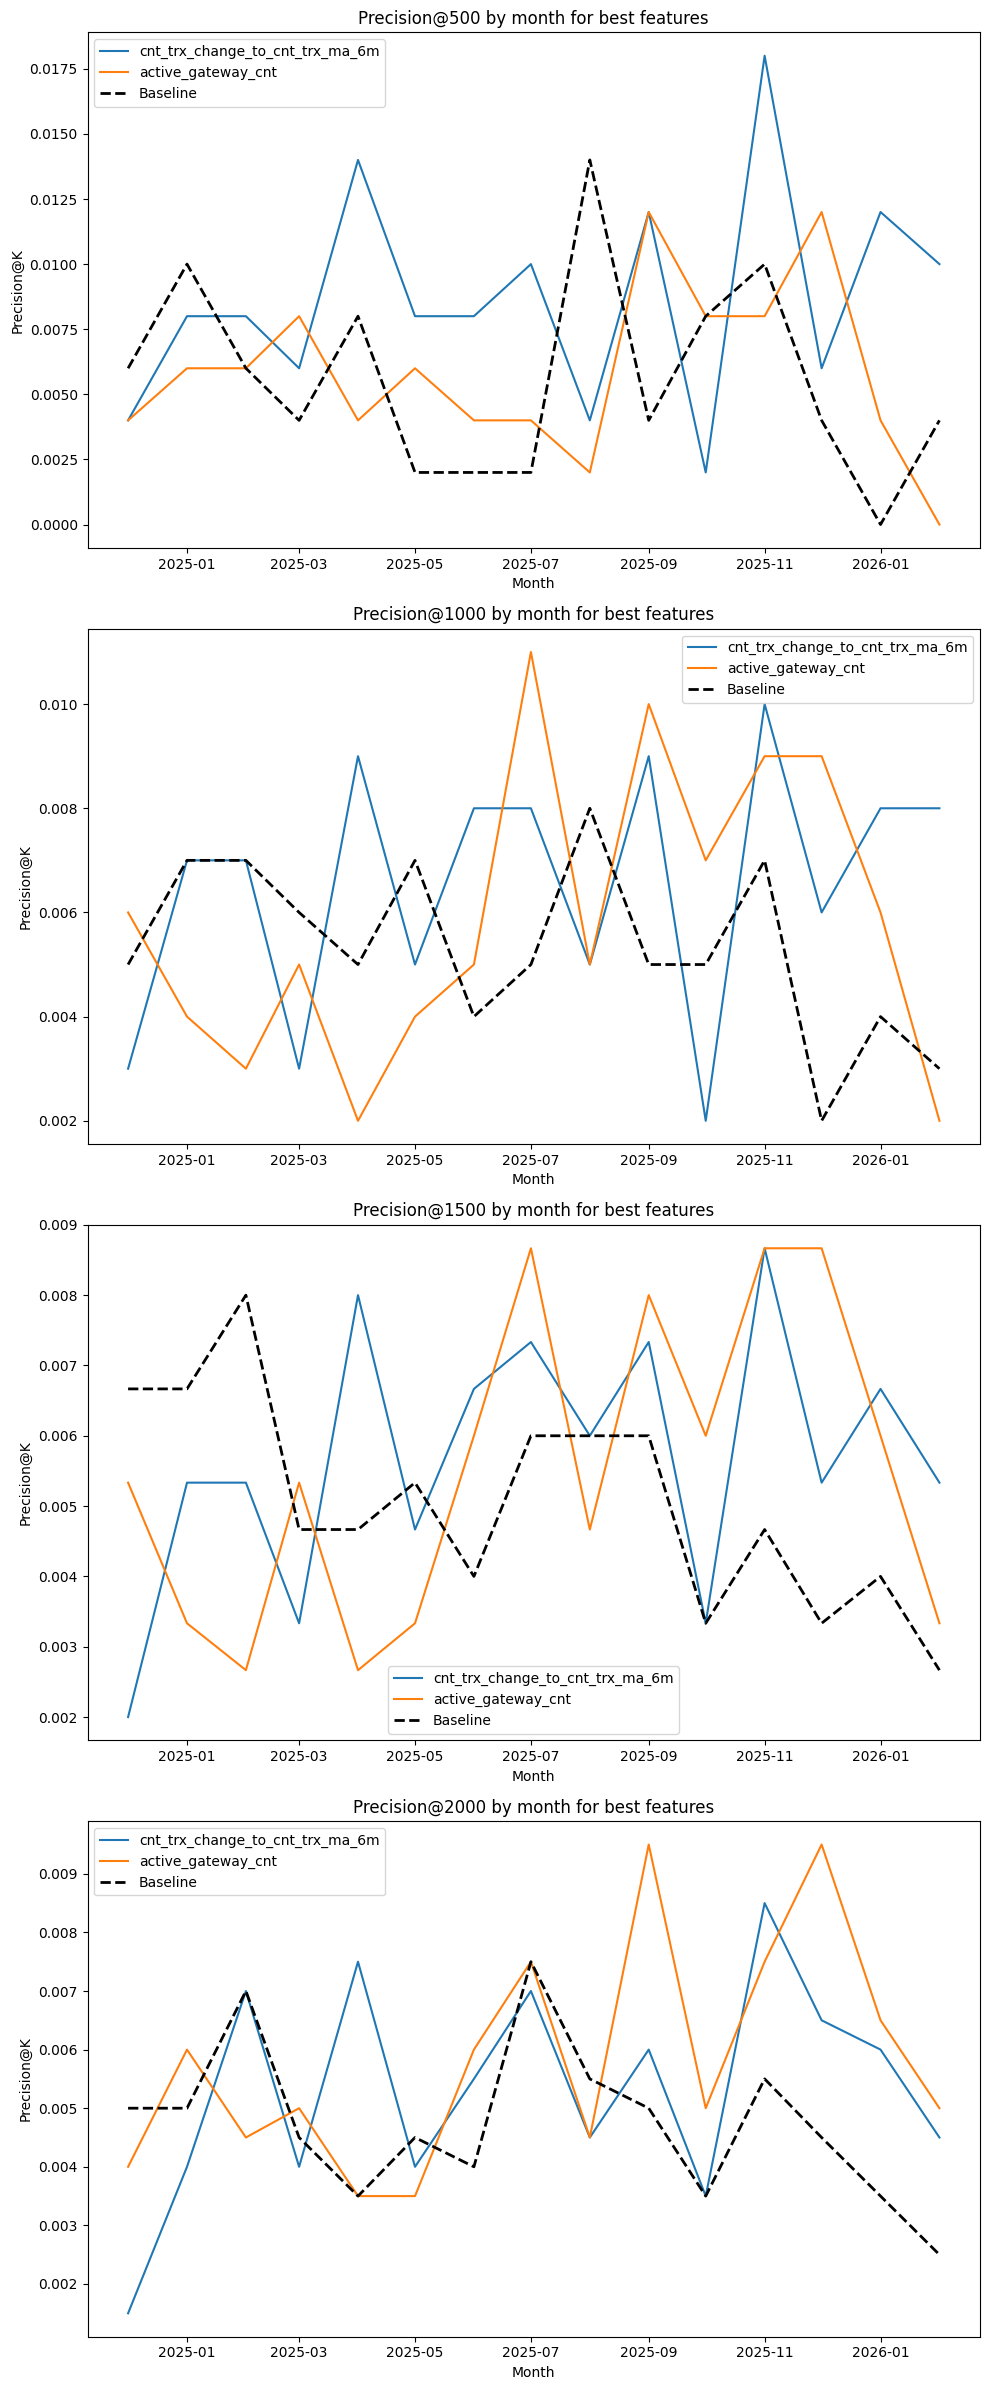

In [53]:
best_rule_based_p1_p2_scoring_cols = [
    # "cnt_trx_change_to_cnt_trx_ma_3m",
    "cnt_trx_change_to_cnt_trx_ma_6m",
    # "cnt_trx_change_to_cnt_trx_ema_3m",
    # "cnt_trx_change_to_cnt_trx_ema_6m",
    # "turnover_change_to_turnover_ma_3m",
    # "turnover_change_to_turnover_ma_6m",
    # "avg_check_wma_3m",
    "active_gateway_cnt",
]

fig, axes = plt.subplots(nrows=len(k_values), ncols=1, figsize=(10, 6 * len(k_values)))

if len(k_values) == 1:
    axes = [axes]

for idx_k, k in enumerate(k_values):
    print(f"\n==== K={k} ====")
    ax = axes[idx_k]
    for col in best_rule_based_p1_p2_scoring_cols:
        stats = precision_at_k_by_month(
            data=df_pred_p1_p2,
            k=k,
            y_true="y",
            score_col=col,
            month_col="month",
        )
        baseline_mean = business_rule_baseline_p1_p2[k]['mean'] if k in business_rule_baseline_p1_p2 else None
        comparison_str = ""
        if baseline_mean is not None:
            diff = stats['mean'] - baseline_mean
            comparison_str = f" | baseline Δ: {diff:.2%}"
        print(
            f"{col:35s} | Precision@{k:<4} = {stats['mean']:.2%} "
            f"(std={stats['std']:.2%}, min={stats['min']:.2%}, max={stats['max']:.2%})"
            + comparison_str
        )

        ax.plot(stats['month_labels'], stats['per_month'], label=col)
    # Базовый бейзлайн всегда одной и той же линией
    ax.plot(stats['month_labels'], business_rule_baseline_p1_p2[k]['per_month'], label='Baseline', color='black', linestyle='--', linewidth=2)
    ax.legend()
    ax.set_title(f'Precision@{k} by month for best features')
    ax.set_xlabel('Month')
    ax.set_ylabel('Precision@K')
plt.tight_layout()

In [54]:
df_p1_p2.info()

<class 'pandas.DataFrame'>
RangeIndex: 336921 entries, 0 to 336920
Data columns (total 67 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   month                                 336921 non-null  datetime64[us]
 1   inn                                   336921 non-null  str           
 2   inn_status                            336921 non-null  category      
 3   top_mcc_group_inn                     336921 non-null  category      
 4   who_is_this_first_inn                 336921 non-null  category      
 5   first_trx_month_inn                   336921 non-null  datetime64[us]
 6   last_active_month_inn                 336921 non-null  datetime64[us]
 7   lifetime_month_streak_inn             336921 non-null  int64         
 8   real_kam_on_inn                       336921 non-null  bool          
 9   has_termination_start                 336921 non-null  bool          


### P3

Критерии релевантности:
- Отсутствие подключённого продукта `P3`
- Статус `'Active'`, `'Reborn'`
- Релевантные MCC (флаг `is_relevant_mcc_p3`)
- Группа MCC `!= 'Charity'`

In [55]:
@dataclass
class P3RuleConfig:
    active_statuses: List[str] = field(default_factory=lambda: ["Active", "Reborn"])
    banned_mcc_groups: List[str] = field(default_factory=lambda: ["Charity"])


class P3BusinessRuleModel(BaseEstimator, ClassifierMixin):
    """
    Rule-based модель релевантности P3.
    """

    required_columns = ["inn_status", "top_mcc_group_inn", "is_relevant_mcc_p3"]

    def __init__(self, config: Optional[P3RuleConfig] = None):
        self.config = config if config is not None else P3RuleConfig()
        self.is_fitted_ = False

    def _validate_input(self, X: pd.DataFrame):
        missing = [c for c in self.required_columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

    def _check_fitted(self):
        if not self.is_fitted_:
            raise RuntimeError("Model is not fitted. Call fit() first.")

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None):
        self._validate_input(X)
        self.is_fitted_ = True
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        self._check_fitted()
        self._validate_input(X)

        pred = (
            X["inn_status"].isin(self.config.active_statuses)
            & ~X["top_mcc_group_inn"].isin(self.config.banned_mcc_groups)
            & X["is_relevant_mcc_p3"]
        ).astype("int8")

        return pred.to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Метод необходим для совместимости с sklearn. Возможные вероятности для Rule-based моделей: 0, 1."""
        pred = self.predict(X)
        proba_1 = pred.astype(float)
        proba_0 = 1.0 - proba_1
        return np.column_stack([proba_0, proba_1])

    def explain_rules(self) -> Dict[str, Any]:
        return {
            "active_statuses": self.config.active_statuses,
            "banned_mcc_groups": self.config.banned_mcc_groups,
            "logic": "prediction=1 if status in active_statuses, top_mcc_group_inn not in banned_mcc_groups and is_relevant_mcc_p3"
        }


X = df_p3.copy()
y = df_p3["target"].astype("int8")

rule_model_p3 = P3BusinessRuleModel()
rule_model_p3.fit(X, y)

df_pred_p3 = X.copy()
df_pred_p3["y"] = y.values
df_pred_p3["y_pred"] = rule_model_p3.predict(X)

Rule-Based Model P3 Validation
Precision@500  = 0.04% (std=0.08%, min=0.00%, max=0.20%)
Precision@1000 = 0.02% (std=0.04%, min=0.00%, max=0.10%)
Precision@1500 = 0.02% (std=0.03%, min=0.00%, max=0.07%)
Precision@2000 = 0.02% (std=0.02%, min=0.00%, max=0.05%)


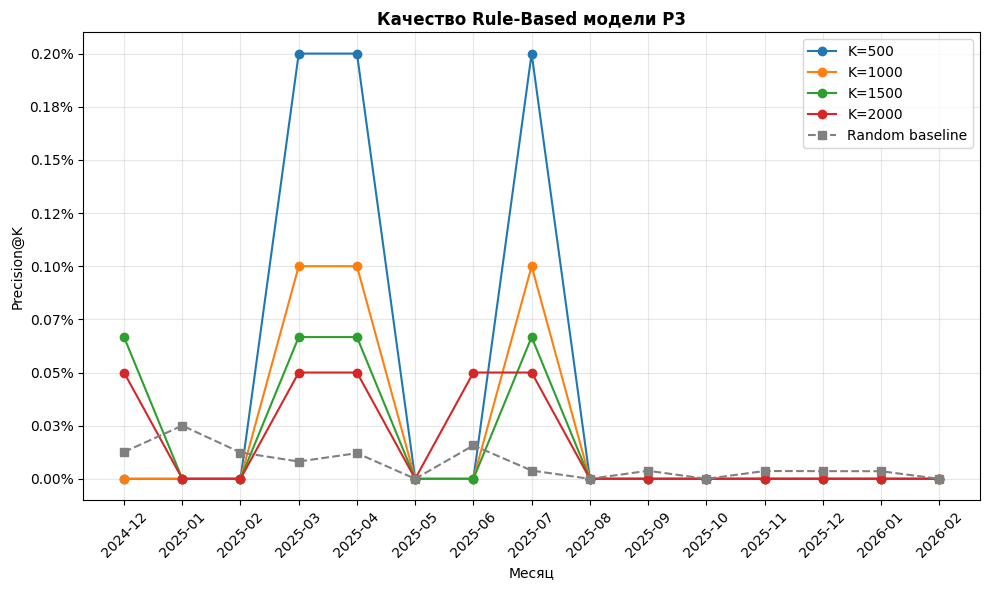

In [56]:
k_values = [500, 1000, 1500, 2000]

print("Rule-Based Model P3 Validation")
business_rule_baseline_p3 = {}


plt.figure(figsize=(10, 6))

for k in k_values:
    stats = precision_at_k_by_month(
        data=df_pred_p3,
        k=k,
        y_true="y",
        score_col="turnover",
        month_col="month",
    )
    business_rule_baseline_p3[k] = stats

    print(
        f"Precision@{k:<4} = {stats['mean']:.2%} "
        f"(std={stats['std']:.2%}, min={stats['min']:.2%}, max={stats['max']:.2%})"
    )

    months = stats.get("month_labels", None)
    precisions = stats["per_month"]
    if months is None:
        months = range(len(precisions))

    formatted_months = months
    try:
        formatted_months = pd.to_datetime(months).strftime('%Y-%m')
    except Exception:
        formatted_months = [str(m) for m in months]

    plt.plot(
        formatted_months, precisions, marker='o', linestyle='-', label=f'K={k}'
    )


random_stats_p3 = random_baseline_p3_stats.get("per_month", None)
if random_stats_p3 is not None:
    try:
        formatted_random_months = pd.to_datetime(random_stats_p3.index).strftime('%Y-%m')
    except Exception:
        formatted_random_months = [str(m) for m in random_stats_p3.index]
    plt.plot(
        formatted_random_months,
        random_stats_p3.values,
        marker='s',
        linestyle='--',
        color='gray',
        label='Random baseline'
    )

plt.title("Качество Rule-Based модели P3", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Precision@K")
plt.xticks(formatted_months, formatted_months, rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Altpay5

Критерии релевантности:
- Отсутствие подключённого продукта `Altpay5`
- Статус `'Active'`, `'Reborn'`
- Только релевантные MCC (флаг `is_relevant_mcc_altpay5`)
- Минимальный порог оборота (флаг `is_relevant_turnover_altpay5`)

In [57]:
@dataclass
class Altpay5RuleConfig:
    active_statuses: List[str] = field(default_factory=lambda: ["Active", "Reborn"])


class Altpay5BusinessRuleModel(BaseEstimator, ClassifierMixin):
    """
    Rule-based модель релевантности Altpay5.
    """

    required_columns = ["inn_status", "is_relevant_mcc_altpay5", "is_relevant_turnover_altpay5"]

    def __init__(self, config: Optional[Altpay5RuleConfig] = None):
        self.config = config if config is not None else Altpay5RuleConfig()
        self.is_fitted_ = False

    def _validate_input(self, X: pd.DataFrame):
        missing = [c for c in self.required_columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

    def _check_fitted(self):
        if not self.is_fitted_:
            raise RuntimeError("Model is not fitted. Call fit() first.")

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None):
        self._validate_input(X)
        self.is_fitted_ = True
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        self._check_fitted()
        self._validate_input(X)

        pred = (
            X["inn_status"].isin(self.config.active_statuses)
            & X["is_relevant_mcc_altpay5"]
            & X["is_relevant_turnover_altpay5"]
        ).astype("int8")

        return pred.to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Метод необходим для совместимости с sklearn. Возможные вероятности для Rule-based моделей: 0, 1."""
        pred = self.predict(X)
        proba_1 = pred.astype(float)
        proba_0 = 1.0 - proba_1
        return np.column_stack([proba_0, proba_1])

    def explain_rules(self) -> Dict[str, Any]:
        return {
            "active_statuses": self.config.active_statuses,
            "logic": "prediction=1 if status in active_statuses, is_relevant_mcc_altpay5 and is_relevant_turnover_altpay5"
        }


X = df_altpay5.copy()
y = df_altpay5["target"].astype("int8")

rule_model_altpay5 = Altpay5BusinessRuleModel()
rule_model_altpay5.fit(X, y)

df_pred_altpay5 = X.copy()
df_pred_altpay5["y"] = y.values
df_pred_altpay5["y_pred"] = rule_model_altpay5.predict(X)

Rule-Based Model P3 Validation
Precision@500  = 0.57% (std=0.23%, min=0.00%, max=1.00%)
Precision@1000 = 0.57% (std=0.33%, min=0.00%, max=1.40%)
Precision@1500 = 0.55% (std=0.31%, min=0.00%, max=1.13%)
Precision@2000 = 0.51% (std=0.27%, min=0.00%, max=1.05%)


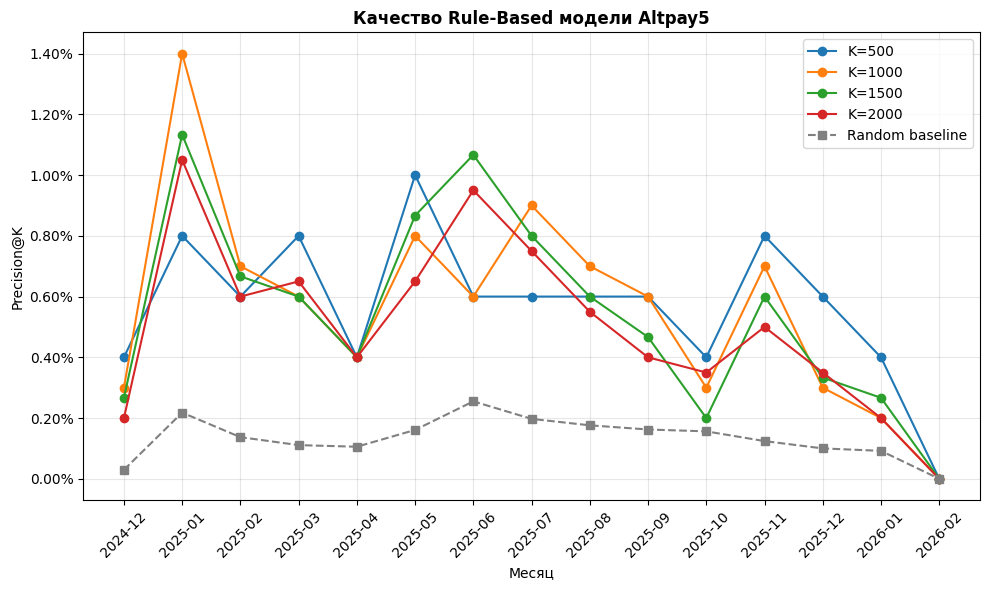

In [58]:
k_values = [500, 1000, 1500, 2000]

print("Rule-Based Model P3 Validation")
business_rule_baseline_altpay5 = {}


plt.figure(figsize=(10, 6))

for k in k_values:
    stats = precision_at_k_by_month(
        data=df_pred_altpay5,
        k=k,
        y_true="y",
        score_col="turnover",
        month_col="month",
    )
    business_rule_baseline_altpay5[k] = stats

    print(
        f"Precision@{k:<4} = {stats['mean']:.2%} "
        f"(std={stats['std']:.2%}, min={stats['min']:.2%}, max={stats['max']:.2%})"
    )

    months = stats.get("month_labels", None)
    precisions = stats["per_month"]
    if months is None:
        months = range(len(precisions))

    formatted_months = months
    try:
        formatted_months = pd.to_datetime(months).strftime('%Y-%m')
    except Exception:
        formatted_months = [str(m) for m in months]

    plt.plot(
        formatted_months, precisions, marker='o', linestyle='-', label=f'K={k}'
    )


random_stats_altpay5 = random_baseline_altpay5_stats.get("per_month", None)
if random_stats_altpay5 is not None:
    try:
        formatted_random_months = pd.to_datetime(random_stats_altpay5.index).strftime('%Y-%m')
    except Exception:
        formatted_random_months = [str(m) for m in random_stats_altpay5.index]
    plt.plot(
        formatted_random_months,
        random_stats_altpay5.values,
        marker='s',
        linestyle='--',
        color='gray',
        label='Random baseline'
    )

plt.title("Качество Rule-Based модели Altpay5", fontdict={'fontweight': 'bold'})
plt.xlabel("Месяц")
plt.ylabel("Precision@K")
plt.xticks(formatted_months, formatted_months, rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()